# Credit Card Fraud Detection — Support Vector Machine (SVM)
**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — ULB Machine Learning Group, Kaggle  
**Algorithm:** SVM (RBF kernel) + SMOTE + GridSearchCV + Threshold Optimisation  
**Team Member:** [I.H.J Premathilaka] | [IT22578532]

---
### Pipeline Overview
1. Install & Import
2. Load Dataset
3. EDA
4. Preprocessing & Feature Engineering
5. Handle Class Imbalance (SMOTE)
6. Train SVM Baseline
7. GridSearchCV Hyperparameter Tuning
8. Best Model Evaluation
9. Threshold Optimisation
10. Cross-Validation
11. Feature Importance (Permutation)
12. **Live Sample Fraud Checker**
13. Final Summary

## 1. Install & Import Libraries

In [1]:
!pip install kagglehub imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q
print('Install complete.')

Install complete.


In [2]:
import kagglehub, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    accuracy_score, matthews_corrcoef
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')
np.random.seed(42)
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Dataset

In [3]:
path     = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
csv_file = os.path.join(path, 'creditcard.csv')
df       = pd.read_csv(csv_file)
print(f'Shape: {df.shape}')
df.head(3)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 3. Exploratory Data Analysis (EDA)

In [4]:
counts = df['Class'].value_counts()
print(f'Rows           : {len(df):,}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')
print(f"Normal  (0)    : {counts[0]:,}  ({counts[0]/len(df)*100:.3f}%)")
print(f"Fraud   (1)    : {counts[1]:,}  ({counts[1]/len(df)*100:.3f}%)")
print()
print('Amount by class:')
print(df.groupby('Class')['Amount'].describe().round(2))

Rows           : 284,807
Missing values : 0
Duplicates     : 1081
Normal  (0)    : 284,315  (99.827%)
Fraud   (1)    : 492  (0.173%)

Amount by class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


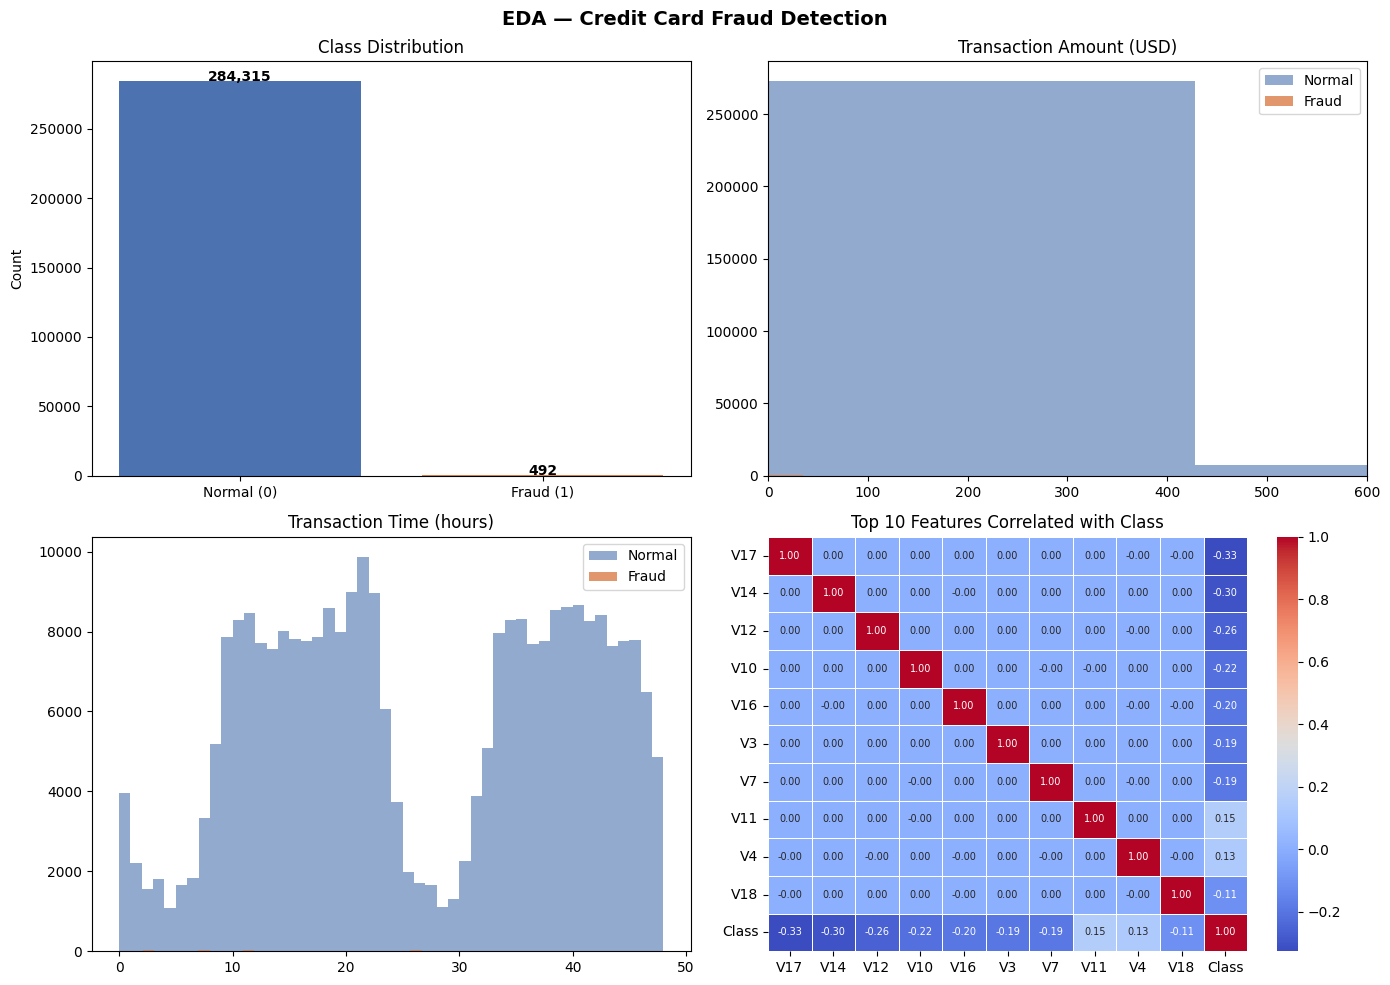

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Credit Card Fraud Detection', fontsize=14, fontweight='bold')

# Class distribution
bars = axes[0,0].bar(['Normal (0)', 'Fraud (1)'],
                      [counts[0], counts[1]], color=['#4C72B0','#DD8452'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for bar, v in zip(bars, [counts[0], counts[1]]):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+300, f'{v:,}',
                   ha='center', fontweight='bold')

# Amount distribution
axes[0,1].hist(df[df['Class']==0]['Amount'], bins=60, alpha=0.6, label='Normal', color='#4C72B0')
axes[0,1].hist(df[df['Class']==1]['Amount'], bins=60, alpha=0.85, label='Fraud',  color='#DD8452')
axes[0,1].set_xlim(0, 600); axes[0,1].legend()
axes[0,1].set_title('Transaction Amount (USD)')

# Time distribution
axes[1,0].hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.6, label='Normal', color='#4C72B0')
axes[1,0].hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.85, label='Fraud',  color='#DD8452')
axes[1,0].legend(); axes[1,0].set_title('Transaction Time (hours)')

# Top correlation heatmap
top_feats = df.corr()['Class'].abs().sort_values(ascending=False)[1:11].index.tolist()
sns.heatmap(df[top_feats+['Class']].corr(), ax=axes[1,1], cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size':7})
axes[1,1].set_title('Top 10 Features Correlated with Class')

plt.tight_layout()
plt.savefig('eda_full.png', dpi=150, bbox_inches='tight')
plt.show()

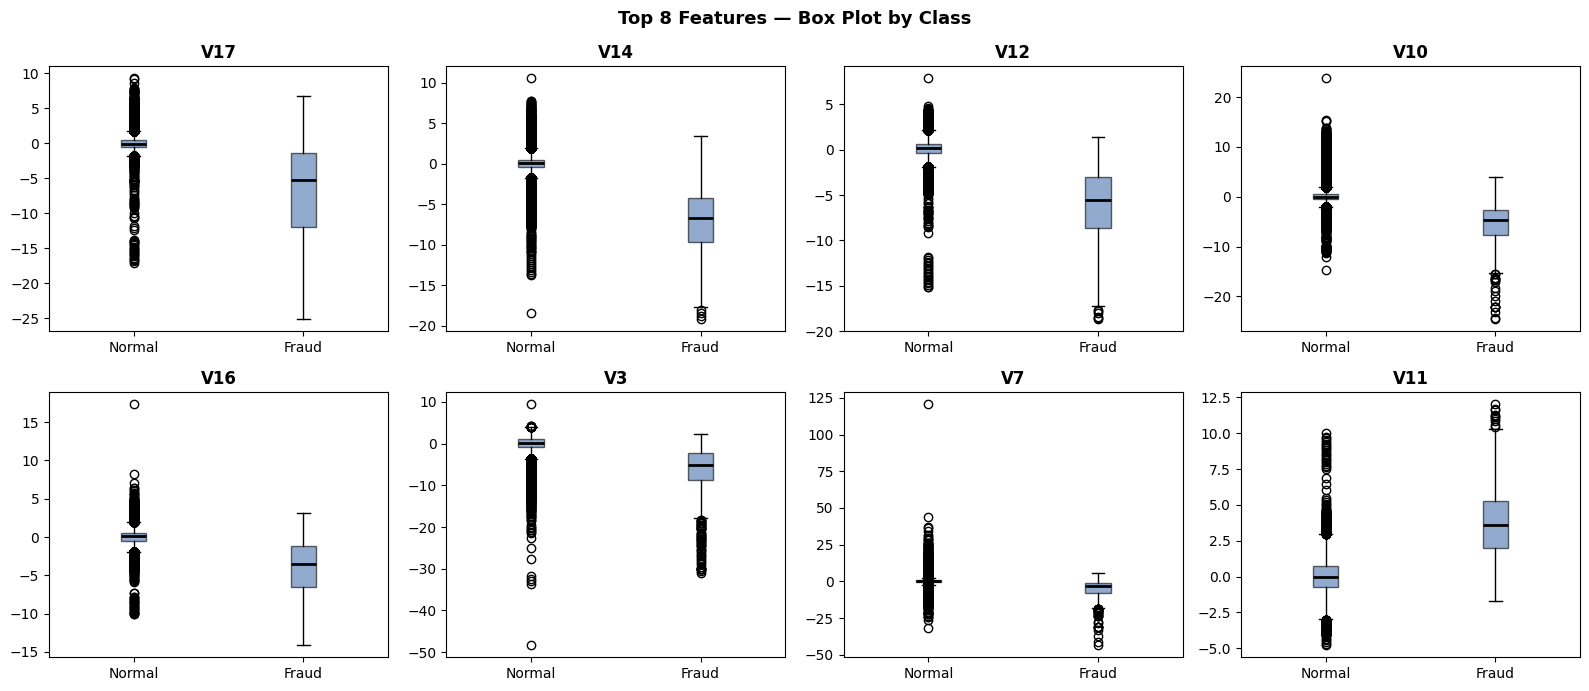

In [6]:
top8 = df.corr()['Class'].abs().sort_values(ascending=False)[1:9].index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Top 8 Features — Box Plot by Class', fontsize=13, fontweight='bold')
for ax, feat in zip(axes.flatten(), top8):
    ax.boxplot(
        [df[df['Class']==0][feat], df[df['Class']==1][feat]],
        labels=['Normal','Fraud'], patch_artist=True,
        boxprops=dict(facecolor='#4C72B0', alpha=0.6),
        medianprops=dict(color='black', linewidth=2)
    )
    ax.set_title(feat, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing & Feature Engineering

In [7]:
# Drop exact duplicates
df = df.drop_duplicates()
print(f'After dedup: {df.shape}')

# Feature engineering: log-Amount (right-skewed), hour-of-day
df['log_Amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] / 3600) % 24

# RobustScaler (resistant to outliers) for Amount and Time
robust_scaler = RobustScaler()
df['scaled_Amount'] = robust_scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = robust_scaler.fit_transform(df[['Time']])

X = df.drop(columns=['Time','Amount','Class'])
y = df['Class']
feature_names = list(X.columns)
print(f'Features ({len(feature_names)}): {feature_names}')

After dedup: (283726, 31)
Features (32): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'log_Amount', 'hour_of_day', 'scaled_Amount', 'scaled_Time']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  fraud={y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Test : {X_test.shape}   fraud={y_test.sum()}  ({y_test.mean()*100:.3f}%)')

Train: (226980, 32)  fraud=378 (0.167%)
Test : (56746, 32)   fraud=95  (0.167%)


## 5. Handle Class Imbalance — RandomUnderSampler + SMOTE
Undersample majority first (10:1), then SMOTE oversample minority to 1:1 balance.

After undersample — Normal:3780 Fraud:378
After SMOTE      — Normal:3780 Fraud:3780
Final training set: (7560, 32)


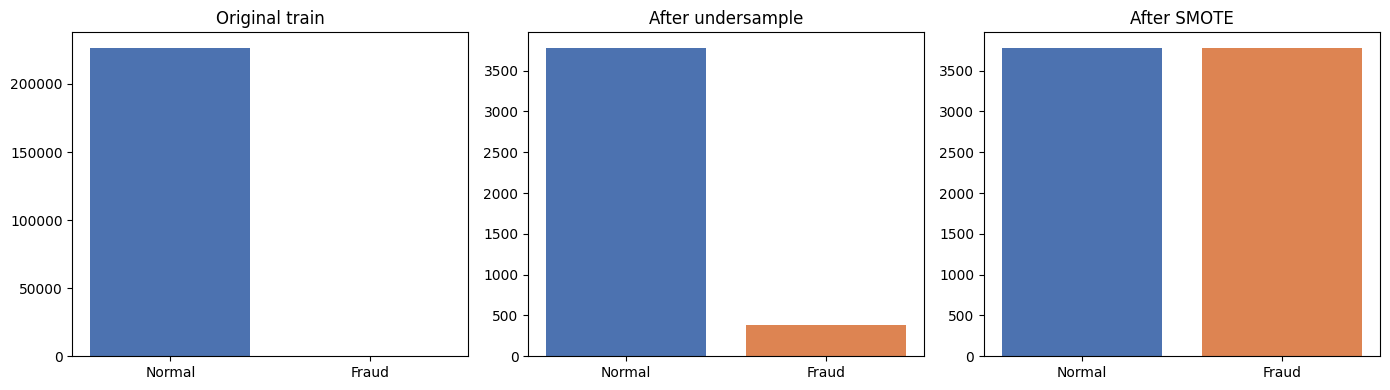

In [9]:
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print(f'After undersample — Normal:{(y_res==0).sum()} Fraud:{(y_res==1).sum()}')

smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)
X_bal, y_bal = smote.fit_resample(X_res, y_res)
print(f'After SMOTE      — Normal:{(y_bal==0).sum()} Fraud:{(y_bal==1).sum()}')
print(f'Final training set: {X_bal.shape}')

fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, vals, title in zip(axes,
    [y_train, y_res, y_bal],
    ['Original train', 'After undersample', 'After SMOTE']):
    c = pd.Series(vals).value_counts()
    ax.bar(['Normal','Fraud'], [c.get(0,0), c.get(1,0)], color=['#4C72B0','#DD8452'])
    ax.set_title(title)
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Train SVM — Baseline

In [10]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale',
                   class_weight='balanced', probability=True, random_state=42))
])
print('Training baseline...')
baseline_pipeline.fit(X_bal, y_bal)
y_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_base, target_names=['Normal','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}   MCC: {matthews_corrcoef(y_test, y_base):.4f}')

Training baseline...
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56651
       Fraud       0.12      0.84      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746

ROC-AUC: 0.9771   MCC: 0.3194


## 7. Hyperparameter Tuning — GridSearchCV

In [11]:
param_grid = {
    'svm__C'      : [0.1, 1.0, 10.0, 100.0],
    'svm__kernel' : ['rbf', 'linear'],
    'svm__gamma'  : ['scale', 'auto'],
}

grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('svm', SVC(class_weight='balanced', probability=True, random_state=42))]),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1, verbose=1, refit=True
)
print('Running GridSearchCV (~5-10 mins on Colab)...')
grid.fit(X_bal, y_bal)
print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')

Running GridSearchCV (~5-10 mins on Colab)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'svm__C': 100.0, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1  : 0.9909


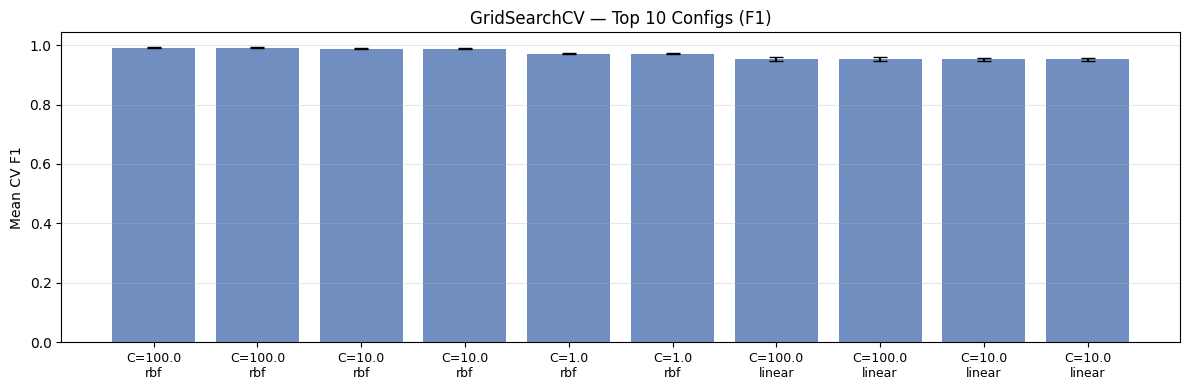

In [12]:
cv_df = pd.DataFrame(grid.cv_results_)
top10 = cv_df.nsmallest(10, 'rank_test_score')
labels = [f"C={r['param_svm__C']}\n{r['param_svm__kernel']}" for _, r in top10.iterrows()]
plt.figure(figsize=(12,4))
plt.bar(range(len(top10)), top10['mean_test_score'],
        yerr=top10['std_test_score'], color='#4C72B0', alpha=0.8, capsize=5)
plt.xticks(range(len(top10)), labels, fontsize=9)
plt.title('GridSearchCV — Top 10 Configs (F1)')
plt.ylabel('Mean CV F1')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Best Model Evaluation

In [13]:
best_model  = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

print('=== Best Model Results ===')
print(classification_report(y_test, y_pred_best, target_names=['Normal','Fraud']))
print(f'ROC-AUC       : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_prob_best):.4f}')
print(f'MCC           : {matthews_corrcoef(y_test, y_pred_best):.4f}')

=== Best Model Results ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56651
       Fraud       0.12      0.78      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.88      0.60     56746
weighted avg       1.00      0.99      0.99     56746

ROC-AUC       : 0.9395
Avg Precision : 0.5632
MCC           : 0.3006


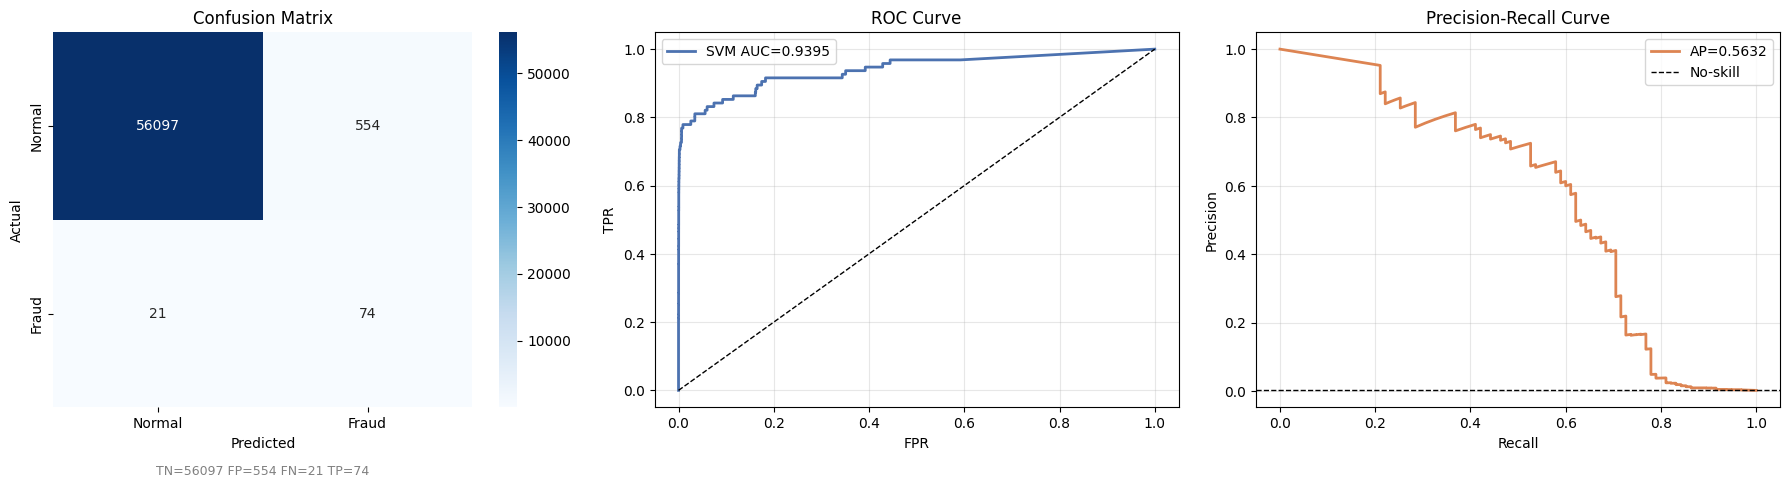

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
tn,fp,fn,tp = cm.ravel()
axes[0].text(0.5,-0.18, f'TN={tn} FP={fp} FN={fn} TP={tp}',
             ha='center', transform=axes[0].transAxes, fontsize=9, color='gray')

fpr,tpr,_ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr,tpr,'#4C72B0',lw=2,label=f'SVM AUC={roc_auc_score(y_test,y_prob_best):.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True,alpha=0.3)

prec,rec,_ = precision_recall_curve(y_test, y_prob_best)
axes[2].plot(rec,prec,'#DD8452',lw=2,label=f'AP={average_precision_score(y_test,y_prob_best):.4f}')
axes[2].axhline(y=y_test.mean(),color='k',linestyle='--',lw=1,label='No-skill')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend(); axes[2].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Threshold Optimisation
Lower the decision threshold to catch more fraud (higher recall at cost of some precision).

Optimal threshold: 0.990
  Precision : 0.5175
  Recall    : 0.6211
  F1        : 0.5646


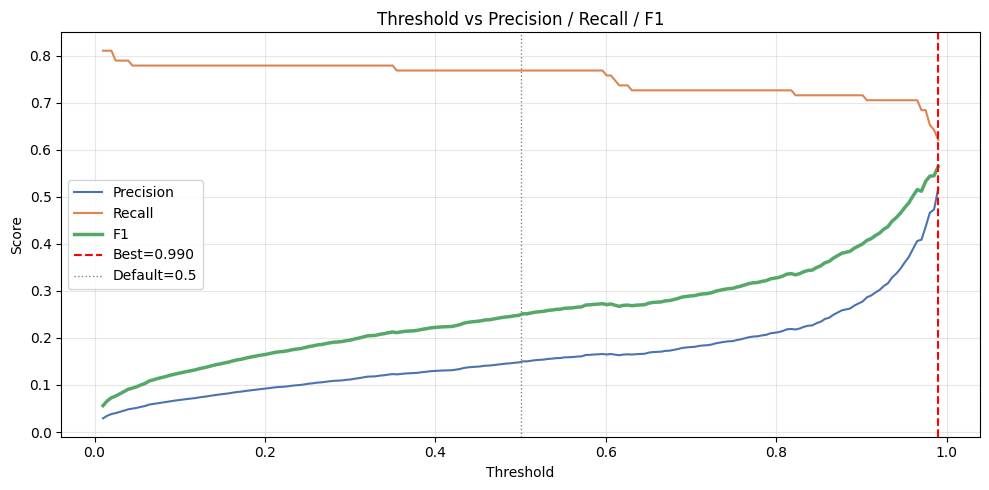


=== At Optimal Threshold ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.52      0.62      0.56        95

    accuracy                           1.00     56746
   macro avg       0.76      0.81      0.78     56746
weighted avg       1.00      1.00      1.00     56746



In [15]:
thresholds = np.linspace(0.01, 0.99, 200)
rows = []
for t in thresholds:
    y_t = (y_prob_best >= t).astype(int)
    rows.append({'t': t,
                 'precision': precision_score(y_test, y_t, zero_division=0),
                 'recall'   : recall_score(y_test, y_t, zero_division=0),
                 'f1'       : f1_score(y_test, y_t, zero_division=0)})
thr_df   = pd.DataFrame(rows)
best_row = thr_df.loc[thr_df['f1'].idxmax()]
best_thr = best_row['t']

print(f'Optimal threshold: {best_thr:.3f}')
print(f'  Precision : {best_row["precision"]:.4f}')
print(f'  Recall    : {best_row["recall"]:.4f}')
print(f'  F1        : {best_row["f1"]:.4f}')

plt.figure(figsize=(10,5))
plt.plot(thr_df['t'], thr_df['precision'], label='Precision', color='#4C72B0')
plt.plot(thr_df['t'], thr_df['recall'],    label='Recall',    color='#DD8452')
plt.plot(thr_df['t'], thr_df['f1'],        label='F1',        color='#55A868', lw=2.5)
plt.axvline(best_thr, color='red', linestyle='--', lw=1.5, label=f'Best={best_thr:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', lw=1, label='Default=0.5')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold vs Precision / Recall / F1')
plt.legend(); plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('threshold.png', dpi=150, bbox_inches='tight')
plt.show()

y_opt = (y_prob_best >= best_thr).astype(int)
print('\n=== At Optimal Threshold ===')
print(classification_report(y_test, y_opt, target_names=['Normal','Fraud']))

## 10. Cross-Validation

5-Fold Cross-Validation:
  F1      : 0.9909 +/- 0.0023  [0.9869 - 0.9934]
  ROC-AUC : 0.9994 +/- 0.0004  [0.9986 - 0.9997]
  Recall  : 0.9971 +/- 0.0021  [0.9934 - 0.9987]


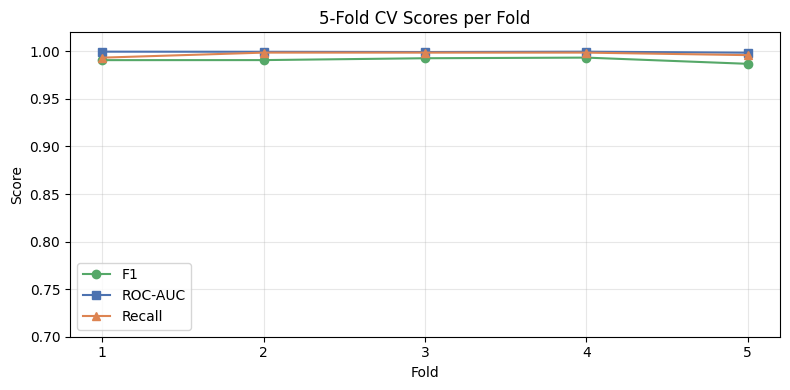

In [16]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(best_model, X_bal, y_bal, cv=cv5, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(best_model, X_bal, y_bal, cv=cv5, scoring='roc_auc',  n_jobs=-1)
cv_rec = cross_val_score(best_model, X_bal, y_bal, cv=cv5, scoring='recall',   n_jobs=-1)

print('5-Fold Cross-Validation:')
for name, arr in [('F1',cv_f1),('ROC-AUC',cv_auc),('Recall',cv_rec)]:
    print(f'  {name:8s}: {arr.mean():.4f} +/- {arr.std():.4f}  [{arr.min():.4f} - {arr.max():.4f}]')

plt.figure(figsize=(8,4))
plt.plot(range(1,6), cv_f1,  marker='o', label='F1',      color='#55A868')
plt.plot(range(1,6), cv_auc, marker='s', label='ROC-AUC', color='#4C72B0')
plt.plot(range(1,6), cv_rec, marker='^', label='Recall',  color='#DD8452')
plt.xticks(range(1,6)); plt.xlabel('Fold'); plt.ylabel('Score')
plt.title('5-Fold CV Scores per Fold')
plt.legend(); plt.grid(True,alpha=0.3); plt.ylim(0.7,1.02)
plt.tight_layout()
plt.savefig('cross_val.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Importance — Permutation Method
SVM has no built-in feature importance. Permutation importance shuffles each feature  
and measures the resulting F1 drop — bigger drop = more important feature.

Computing permutation importance (~2-3 mins)...
Top 15 features:
      Feature  Importance      Std
scaled_Amount    0.139164 0.001741
   log_Amount    0.117641 0.001867
          V14    0.085342 0.003985
          V12    0.077507 0.003292
  scaled_Time    0.063188 0.003380
          V10    0.058614 0.003850
           V8    0.050080 0.003430
           V3    0.048344 0.002444
           V6    0.044311 0.003371
  hour_of_day    0.039246 0.003566
          V16    0.036365 0.002213
           V5    0.036190 0.002467
           V4    0.033750 0.005388
          V25    0.032594 0.002374
          V19    0.030647 0.003781


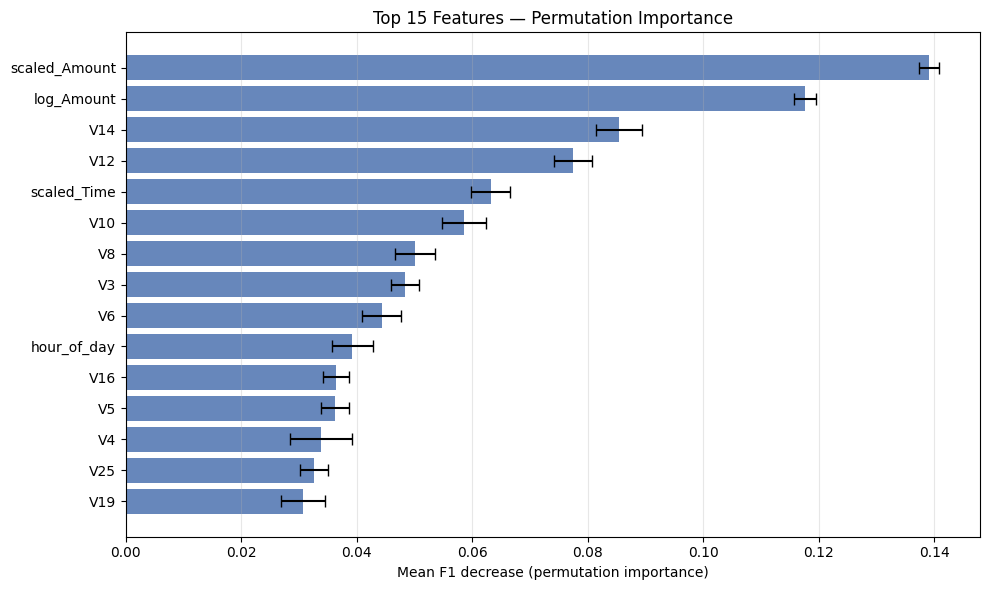

In [17]:
print('Computing permutation importance (~2-3 mins)...')
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1', n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=False)

print('Top 15 features:')
print(perm_df.head(15).to_string(index=False))

top15 = perm_df.head(15)
plt.figure(figsize=(10,6))
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1],
         xerr=top15['Std'][::-1], color='#4C72B0', alpha=0.85, capsize=4)
plt.xlabel('Mean F1 decrease (permutation importance)')
plt.title('Top 15 Features — Permutation Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Live Sample Fraud Checker

Four types of tests:
- **Test 1** — Known FRAUD transaction from the test set
- **Test 2** — Known NORMAL transaction from the test set
- **Test 3** — Batch of 10 random samples with full report
- **Test 4** — Custom manual transaction (edit the values yourself)

In [18]:
def predict_transaction(sample_df, model, threshold=0.5, show_top_features=True):
    """
    Predict whether a single transaction is fraud or normal.

    Parameters
    ----------
    sample_df        : pd.DataFrame with same feature columns as training
    model            : fitted pipeline (scaler + SVM)
    threshold        : decision threshold (default 0.5, use best_thr for optimal)
    show_top_features: print the top 5 features that contributed most risk

    Returns
    -------
    prediction (0/1), fraud_probability (float)
    """
    prob  = model.predict_proba(sample_df)[0][1]
    pred  = int(prob >= threshold)
    label = 'FRAUD'   if pred == 1 else 'NORMAL'
    icon  = 'X' if pred == 1 else 'OK'
    risk  = 'HIGH'   if prob >= 0.75 else ('MEDIUM' if prob >= 0.40 else 'LOW')

    print('=' * 54)
    print(f'  [{icon}] PREDICTION   : {label}')
    print(f'      Fraud probability: {prob:.4f}  ({prob*100:.2f}%)')
    print(f'      Risk level       : {risk}')
    print(f'      Decision threshold: {threshold:.3f}')
    print('=' * 54)

    if show_top_features and perm_df is not None:
        top5_feats = perm_df.head(5)['Feature'].tolist()
        print('  Top 5 fraud-risk features for this transaction:')
        for f in top5_feats:
            if f in sample_df.columns:
                print(f'    {f:20s} = {sample_df[f].values[0]:.4f}')
        print()

    return pred, prob

print('predict_transaction() function ready.')
print(f'Optimal threshold: {best_thr:.3f}')

predict_transaction() function ready.
Optimal threshold: 0.990


In [19]:
# ── TEST 1: Known FRAUD transaction ──────────────────────────────
fraud_idx    = X_test.index[y_test.values == 1]
sample_fraud = X_test.loc[[fraud_idx[0]]]
actual1      = y_test.loc[fraud_idx[0]]

print(f'Actual class: {"FRAUD" if actual1==1 else "NORMAL"}\n')
pred1, prob1 = predict_transaction(sample_fraud, best_model, threshold=best_thr)

correct = (pred1 == actual1)
print(f'  Correct prediction: {"YES" if correct else "NO"}')

Actual class: FRAUD

  [X] PREDICTION   : FRAUD
      Fraud probability: 1.0000  (100.00%)
      Risk level       : HIGH
      Decision threshold: 0.990
  Top 5 fraud-risk features for this transaction:
    scaled_Amount        = 0.7640
    log_Amount           = 4.3559
    V14                  = -3.8229
    V12                  = -3.9934
    scaled_Time          = -0.1238

  Correct prediction: YES


In [20]:
# ── TEST 2: Known NORMAL transaction ─────────────────────────────
normal_idx    = X_test.index[y_test.values == 0]
sample_normal = X_test.loc[[normal_idx[0]]]
actual2       = y_test.loc[normal_idx[0]]

print(f'Actual class: {"FRAUD" if actual2==1 else "NORMAL"}\n')
pred2, prob2 = predict_transaction(sample_normal, best_model, threshold=best_thr)

correct2 = (pred2 == actual2)
print(f'  Correct prediction: {"YES" if correct2 else "NO"}')

Actual class: NORMAL

  [OK] PREDICTION   : NORMAL
      Fraud probability: 0.0003  (0.03%)
      Risk level       : LOW
      Decision threshold: 0.990
  Top 5 fraud-risk features for this transaction:
    scaled_Amount        = -0.1460
    log_Amount           = 2.5257
    V14                  = -0.2928
    V12                  = 0.4651
    scaled_Time          = -0.2750

  Correct prediction: YES


In [21]:
# ── TEST 3: Batch check — 10 random samples ───────────────────────
np.random.seed(99)
idx_batch   = np.random.choice(X_test.index, size=10, replace=False)
X_batch     = X_test.loc[idx_batch]
y_batch     = y_test.loc[idx_batch]

probs_batch = best_model.predict_proba(X_batch)[:,1]
preds_batch = (probs_batch >= best_thr).astype(int)

report = pd.DataFrame({
    'Actual'    : ['FRAUD' if v==1 else 'NORMAL' for v in y_batch],
    'Predicted' : ['FRAUD' if v==1 else 'NORMAL' for v in preds_batch],
    'Fraud_Prob': probs_batch.round(4),
    'Risk'      : ['HIGH' if p>=0.75 else ('MEDIUM' if p>=0.40 else 'LOW') for p in probs_batch],
    'Correct'   : ['YES' if a==p else 'NO' for a,p in zip(y_batch, preds_batch)]
})

print('=== Batch Prediction Report (10 random samples) ===')
print(report.to_string())
print(f'\nAccuracy on batch: {(report["Correct"]=="YES").mean()*100:.0f}%')

=== Batch Prediction Report (10 random samples) ===
   Actual Predicted  Fraud_Prob  Risk Correct
0  NORMAL    NORMAL      0.0000   LOW     YES
1  NORMAL    NORMAL      0.0000   LOW     YES
2  NORMAL    NORMAL      0.0000   LOW     YES
3  NORMAL     FRAUD      0.9926  HIGH      NO
4  NORMAL    NORMAL      0.0000   LOW     YES
5  NORMAL    NORMAL      0.0000   LOW     YES
6  NORMAL    NORMAL      0.0000   LOW     YES
7  NORMAL    NORMAL      0.0000   LOW     YES
8  NORMAL    NORMAL      0.0000   LOW     YES
9  NORMAL    NORMAL      0.0000   LOW     YES

Accuracy on batch: 90%


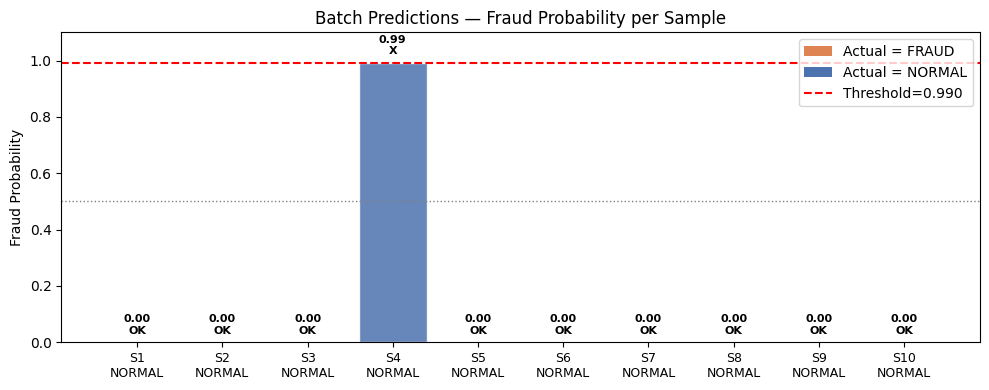

In [22]:
# Visualise batch results as a colour-coded chart
colors = ['#DD8452' if a=='FRAUD' else '#4C72B0' for a in report['Actual']]
plt.figure(figsize=(10,4))
bars = plt.bar(range(10), report['Fraud_Prob'], color=colors, alpha=0.85, edgecolor='white')
plt.axhline(y=best_thr, color='red', linestyle='--', lw=1.5, label=f'Threshold={best_thr:.3f}')
plt.axhline(y=0.5, color='gray', linestyle=':', lw=1, label='Default=0.5')
plt.xticks(range(10), [f'S{i+1}\n{a}' for i,a in enumerate(report['Actual'])], fontsize=9)
plt.ylabel('Fraud Probability')
plt.title('Batch Predictions — Fraud Probability per Sample')
plt.ylim(0, 1.1)
for i, (v, c) in enumerate(zip(report['Fraud_Prob'], report['Correct'])):
    plt.text(i, v + 0.03, f'{v:.2f}\n{"OK" if c=="YES" else "X"}',
             ha='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#DD8452', label='Actual = FRAUD'),
    Patch(facecolor='#4C72B0', label='Actual = NORMAL')
]
plt.legend(handles=legend_elements + [
    plt.Line2D([0],[0],color='red',linestyle='--',label=f'Threshold={best_thr:.3f}')])
plt.tight_layout()
plt.savefig('batch_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── TEST 4: Custom manual transaction ────────────────────────────
# Edit any of the V1-V28 values or Amount/Time to test your own transaction.
# These default values are the very first row from the original dataset.

my_amount  = 149.62    # transaction amount in USD
my_time    = 0.0       # seconds since first transaction in dataset

custom = {
    'V1' :-1.3598, 'V2' :-0.0728, 'V3' : 2.5364, 'V4' : 1.3782,
    'V5' :-0.3383, 'V6' :-0.4683, 'V7' : 0.2076, 'V8' : 0.0258,
    'V9' : 0.4040, 'V10': 0.2253, 'V11':-0.6295, 'V12': 0.3280,
    'V13':-0.0673, 'V14':-0.2702, 'V15':-0.3984, 'V16':-0.0815,
    'V17': 0.3613, 'V18': 0.1249, 'V19': 0.1417, 'V20':-0.0131,
    'V21':-0.0155, 'V22': 0.0267, 'V23':-0.0108, 'V24': 0.1242,
    'V25':-0.1185, 'V26': 0.0147, 'V27': 0.0097, 'V28': 0.0030,
    'log_Amount'  : np.log1p(my_amount),
    'hour_of_day' : (my_time / 3600) % 24,
    'scaled_Amount': robust_scaler.transform([[my_amount]])[0][0],
    'scaled_Time'  : robust_scaler.transform([[my_time]])[0][0],
}

custom_df = pd.DataFrame([custom])[feature_names]

print(f'Custom transaction — Amount: ${my_amount}  Time: {my_time}s')
print()
predict_transaction(custom_df, best_model, threshold=best_thr)

Custom transaction — Amount: $149.62  Time: 0.0s

  [OK] PREDICTION   : NORMAL
      Fraud probability: 0.0000  (0.00%)
      Risk level       : LOW
      Decision threshold: 0.990
  Top 5 fraud-risk features for this transaction:
    scaled_Amount        = -0.9935
    log_Amount           = 5.0148
    V14                  = -0.2702
    V12                  = 0.3280
    scaled_Time          = -0.9953



(0, np.float64(1.0000000994736041e-07))

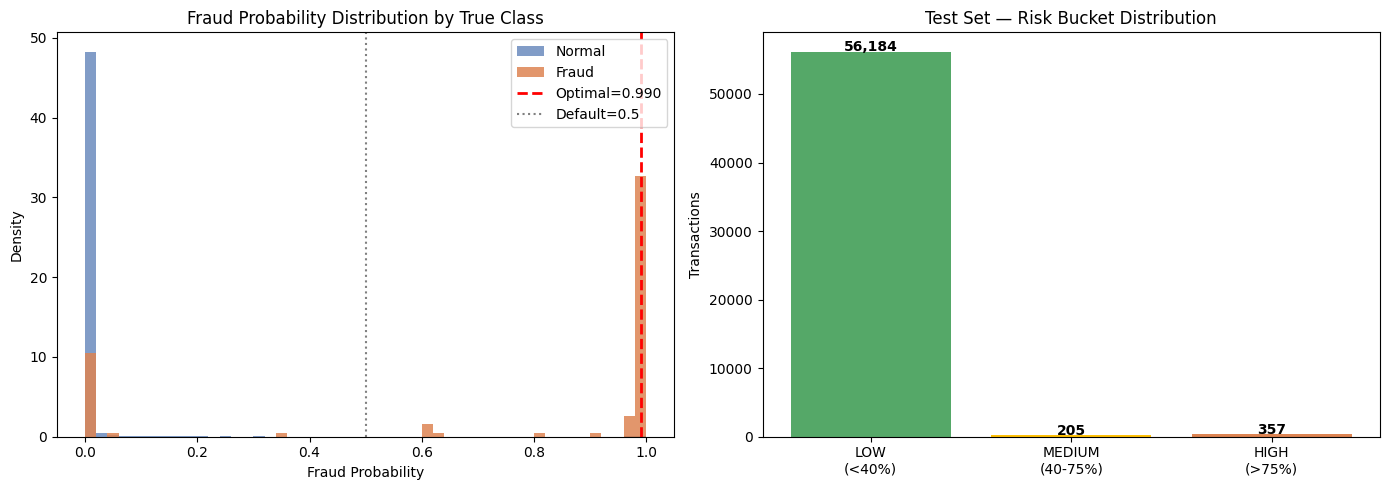

In [24]:
# Full test-set probability distribution with risk buckets
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(y_prob_best[y_test==0], bins=50, alpha=0.7,
             label='Normal', color='#4C72B0', density=True)
axes[0].hist(y_prob_best[y_test==1], bins=50, alpha=0.85,
             label='Fraud',  color='#DD8452', density=True)
axes[0].axvline(best_thr, color='red', linestyle='--', lw=2, label=f'Optimal={best_thr:.3f}')
axes[0].axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default=0.5')
axes[0].set_xlabel('Fraud Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('Fraud Probability Distribution by True Class')
axes[0].legend()

risk_counts = [
    (y_prob_best < 0.40).sum(),
    ((y_prob_best >= 0.40) & (y_prob_best < 0.75)).sum(),
    (y_prob_best >= 0.75).sum()
]
axes[1].bar(['LOW\n(<40%)', 'MEDIUM\n(40-75%)', 'HIGH\n(>75%)'],
             risk_counts, color=['#55A868','#FFC107','#DD8452'])
axes[1].set_title('Test Set — Risk Bucket Distribution')
axes[1].set_ylabel('Transactions')
for i, v in enumerate(risk_counts):
    axes[1].text(i, v+30, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Final Summary for Report

In [25]:
y_final = best_model.predict(X_test)
y_opt   = (y_prob_best >= best_thr).astype(int)

print('=' * 58)
print('  FINAL SVM RESULTS')
print('=' * 58)
print(f'  Algorithm         : SVM')
print(f'  Kernel            : {grid.best_params_["svm__kernel"]}')
print(f'  C                 : {grid.best_params_["svm__C"]}')
print(f'  Gamma             : {grid.best_params_["svm__gamma"]}')
print(f'  Sampling          : UnderSampler + SMOTE')
print(f'  Scaler            : StandardScaler')
print(f'  Optimal threshold : {best_thr:.3f}')
print()
print('  At default threshold (0.5):')
print(f'    Accuracy    : {accuracy_score(y_test, y_final):.4f}')
print(f'    Precision   : {precision_score(y_test, y_final):.4f}')
print(f'    Recall      : {recall_score(y_test, y_final):.4f}')
print(f'    F1          : {f1_score(y_test, y_final):.4f}')
print(f'    ROC-AUC     : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'    Avg Prec    : {average_precision_score(y_test, y_prob_best):.4f}')
print(f'    MCC         : {matthews_corrcoef(y_test, y_final):.4f}')
print()
print(f'  At optimal threshold ({best_thr:.3f}):')
print(f'    Precision   : {precision_score(y_test, y_opt):.4f}')
print(f'    Recall      : {recall_score(y_test, y_opt):.4f}')
print(f'    F1          : {f1_score(y_test, y_opt):.4f}')
print(f'    MCC         : {matthews_corrcoef(y_test, y_opt):.4f}')
print()
print('  Dataset : Credit Card Fraud Detection')
print('  Source  : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')
print('  Citation: Dal Pozzolo et al., IEEE SSCI 2015')
print('=' * 58)

  FINAL SVM RESULTS
  Algorithm         : SVM
  Kernel            : rbf
  C                 : 100.0
  Gamma             : scale
  Sampling          : UnderSampler + SMOTE
  Scaler            : StandardScaler
  Optimal threshold : 0.990

  At default threshold (0.5):
    Accuracy    : 0.9899
    Precision   : 0.1178
    Recall      : 0.7789
    F1          : 0.2047
    ROC-AUC     : 0.9395
    Avg Prec    : 0.5632
    MCC         : 0.3006

  At optimal threshold (0.990):
    Precision   : 0.5175
    Recall      : 0.6211
    F1          : 0.5646
    MCC         : 0.5661

  Dataset : Credit Card Fraud Detection
  Source  : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
  Citation: Dal Pozzolo et al., IEEE SSCI 2015
